## __Data Cleaning__

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Tatanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    object 
 10  Cabin        0 non-null      float64
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [14]:
df['Cabin'] = pd.to_numeric(df['Cabin'], errors='coerce')


In [5]:
dup_count = df.duplicated().sum()
print(f"Duplicated rows: {dup_count}")

null_count = df.isnull().sum()
if null_count.sum() == 0:
    print("No missing valued detected.")
else:
    print("Missing valued detected.")
    print(null_count[null_count>0])

Duplicated rows: 0
Missing valued detected.
Age       86
Fare       1
Cabin    327
dtype: int64


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Data Filled in median")

Data Filled in median


In [16]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mean)
print("Data filled in mean.")

Data filled in mean.


In [10]:
df['Fare'] = df['Fare'].fillna(df['Fare'].median)

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,<bound method Series.mean of 0 NaN\n1 ...,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0,<bound method Series.mean of 0 NaN\n1 ...,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,<bound method Series.mean of 0 NaN\n1 ...,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,<bound method Series.mean of 0 NaN\n1 ...,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,<bound method Series.mean of 0 NaN\n1 ...,S


<Axes: xlabel='Survived', ylabel='count'>

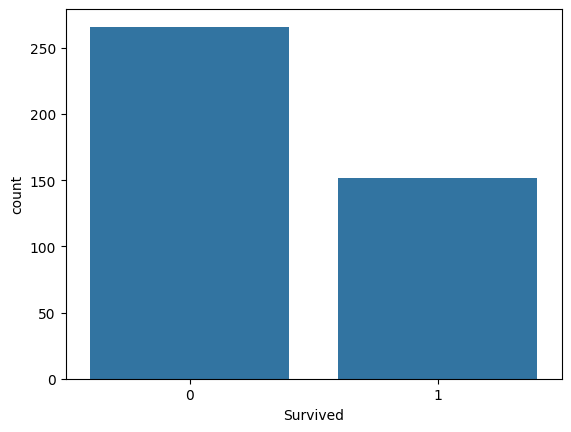

In [19]:
sns.countplot(data=df, x='Survived')

<Axes: xlabel='Sex', ylabel='count'>

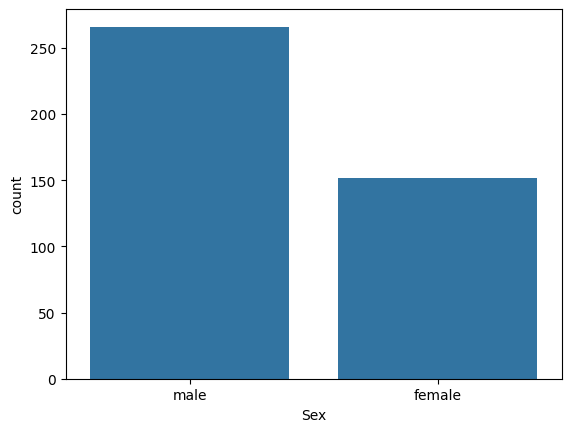

In [20]:
sns.countplot(data=df, x='Sex')

<Axes: xlabel='Embarked', ylabel='count'>

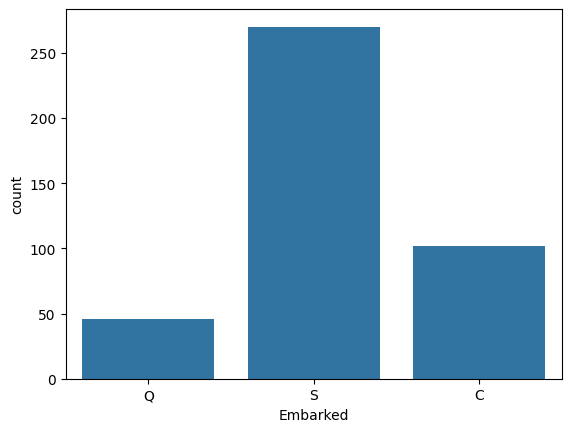

In [21]:
sns.countplot(data=df, x='Embarked')

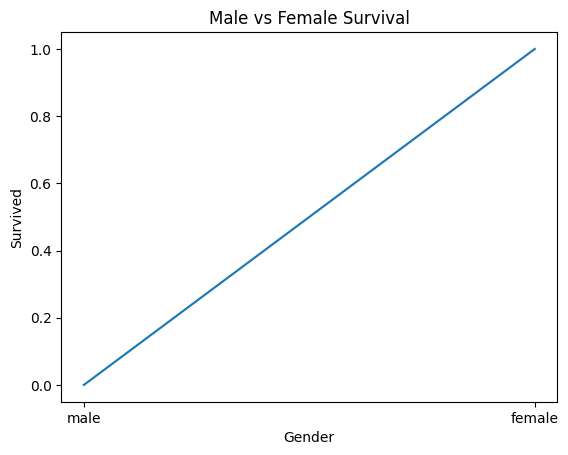

In [28]:
plt.title("Male vs Female Survival")
sns.lineplot(data=df, x='Sex', y='Survived')
plt.xlabel("Gender")
plt.ylabel("Survived")
plt.show()

## Automated Data Cleaning